In [56]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.preprocessing import LabelEncoder, StandardScaler

In [ ]:
df = pd.read_csv('D://sampledata//test//ford.csv')
df

# EDA

In [ ]:
df.info()

In [ ]:
df.describe()

In [ ]:
df.isnull().sum()

In [ ]:
df.isna().sum()

In [ ]:
df.duplicated().sum()

In [ ]:
df

In [ ]:
sns.histplot(data=df, x='price', kde=True) # output column

In [ ]:
df['model'].value_counts()

In [ ]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [ ]:
sns.boxplot(data=df, x='year', y='price')
plt.xticks(rotation=90)
plt.tight_layout()

In [ ]:
sns.scatterplot(data=df, x='mileage', y='price')

In [ ]:
sns.boxplot(data=df, x='engineSize', y ='price')

In [ ]:
sns.boxplot(data=df, x='transmission', y='price')

In [ ]:
df

In [ ]:
sns.boxplot(data=df, x='fuelType', y='price')

In [ ]:
sns.boxplot(data=df, x='model', y='price')
plt.xticks(rotation=90)
plt.show()

In [ ]:
sns.scatterplot(data=df, x='tax', y='price')
plt.xticks(rotation=90)
plt.show()

In [ ]:
sns.scatterplot(data=df, x='mpg', y='price')


In [ ]:
X = df.drop(columns='price', axis=1)
y = df['price']

In [ ]:
X

In [ ]:
X_one_encode = pd.get_dummies(X, columns=['model','transmission','fuelType'], drop_first=True, dtype='int64')

In [57]:
X_one_encode

,year,mileage,tax,mpg,engineSize,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Escort,model_ Fiesta,...,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus,transmission_Manual,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,2017,15944,150,57.7,1.0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
1,2018,9083,150,57.7,1.0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
2,2017,12456,150,57.7,1.0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
3,2019,10460,145,40.3,1.5,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,1
4,2019,1482,145,48.7,1.0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17961,2017,16700,150,47.1,1.4,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
17962,2014,40700,30,57.7,1.0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
17963,2015,7010,20,67.3,1.6,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
17964,2018,5007,145,57.7,1.2,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1


In [58]:
scaler = StandardScaler()

cols = ['year',	'mileage', 'tax', 'mpg', 'engineSize']
X_one_encode[cols] = scaler.fit_transform(X_one_encode[cols])

In [59]:
X_one_encode

,year,mileage,tax,mpg,engineSize,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Escort,model_ Fiesta,...,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus,transmission_Manual,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,0.065128,-0.380998,0.591358,-0.020442,-0.811386,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
1,0.552866,-0.733359,0.591358,-0.020442,-0.811386,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
2,0.065128,-0.560132,0.591358,-0.020442,-0.811386,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
3,1.040605,-0.662640,0.510727,-1.738890,0.345070,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,1
4,1.040605,-1.123724,0.510727,-0.909294,-0.811386,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17961,0.065128,-0.342172,0.591358,-1.067312,0.113779,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
17962,-1.398088,0.890398,-1.343791,-0.020442,-0.811386,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
17963,-0.910349,-0.839822,-1.505053,0.927668,0.576362,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
17964,0.552866,-0.942690,0.510727,-0.020442,-0.348804,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1


In [60]:
from sklearn.model_selection import  train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [61]:
X_train, X_test, y_train, y_test = train_test_split(X_one_encode, y, test_size=0.33, random_state=42)

In [62]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [63]:
y_pred = model.predict(X_test)

In [64]:
r2 = r2_score(y_test, y_pred)
r2

0.8402100144860558

In [65]:
X_test.shape

(5929, 34)

In [66]:
n = X_test.shape[0]
p = X_test.shape[1]
adj_r2 = 1 - ((1-r2)*(n-1))/(n-p-1)
print('Adjust R2 score: ',adj_r2)

Adjust R2 score:  0.8392882534566235


In [67]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

MAE: 1377.1906210032944
MSE: 3621812.0120520145


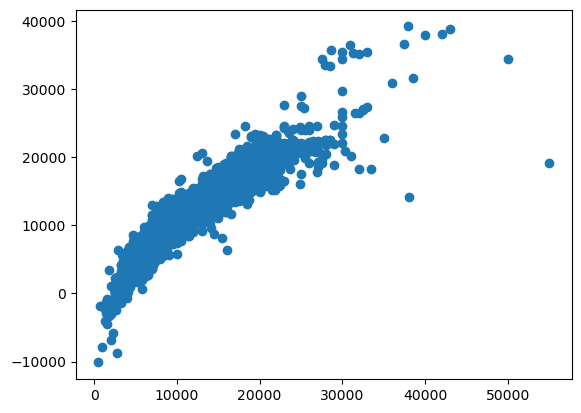

In [68]:
plt.scatter(y_test, y_pred)

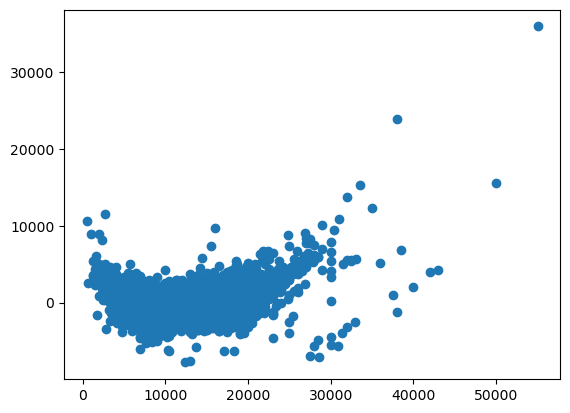

In [69]:
residual = y_test - y_pred
plt.scatter(y_test, residual)